# H5: Антиколлапсные интервенции

## Гипотеза

Diversity-aware политика рекомендаций, принудительно повышающая разнообразие 
предлагаемых объектов, **сохраняет дисперсию** пользовательского распределения 
значительно лучше, чем стандартный top-K, при приемлемой потере качества.

Формально: если $\Pi_{\text{div}}$ — diversity-aware политика, а $\Pi_{\text{top-K}}$ — базовая, то:
$$\operatorname{tr}\bigl(\hat{\Sigma}_T^u \mid \Pi_{\text{div}}\bigr) \;>\; \operatorname{tr}\bigl(\hat{\Sigma}_T^u \mid \Pi_{\text{top-K}}\bigr)$$

## Мотивация

Стандартные системы оптимизируют **краткосрочную точность** (CTR). 
Но при повторном обучении на собственных логах это приводит к feedback loop: 
система рекомендует всё более узкое подмножество «популярных» объектов -> 
пользователи дрейфуют к одному аттрактору -> **эхо-камера**.

Интервенции нарушают этот цикл, вводя **принудительное разнообразие**.

## Компромисс quality vs. diversity

Любая интервенция создаёт компромисс:

| Больше разнообразия | Меньше разнообразия |
|--------------------|---------------------|
| ↑ сохранение tr(Σ̂) | ↑ краткосрочное качество (CTR) |
| ↑ долгосрочная ценность | ↑ немедленное соответствие предпочтениям |
| ↓ риск эхо-камеры | ↓ защита от коллапса |

Задача H5 — найти интервенцию с наилучшим соотношением на **Pareto-фронте**.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from pathlib import Path
from torch.utils.data import DataLoader

from sim.environment import SimulationEnvironment, ExperimentDataset, _PairDataset
from sim.user_generator import GMMUserGenerator
from sim.click_model import ClickModel
from models.rec_models import RecModel
from models.serving import ServingPolicy

matplotlib.rcParams['figure.dpi'] = 120
FIGURES_DIR = Path('../paper/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EMB_DIM = 8
N_USERS = 200
N_ITEMS = 200
K_GMM = 3
K_REC = 10
T = 100
PERIOD = 10
INTER_DIST = 4.0
SIGMA_K = 0.8
USER_DRIFT = 0.005
ADHERENCE = 0.7
N_SEEDS = 3

def make_clustered_setup(seed=42):
 np.random.seed(seed)
 torch.manual_seed(seed)
 means, covs, weights = [], [], []
 for k in range(K_GMM):
 angle = 2 * np.pi * k / K_GMM
 m = np.zeros(EMB_DIM)
 m[0] = INTER_DIST * np.cos(angle)
 m[1] = INTER_DIST * np.sin(angle)
 means.append(m)
 covs.append(SIGMA_K**2 * np.eye(EMB_DIM))
 weights.append(1.0 / K_GMM)

 gen = GMMUserGenerator(means, covs, weights, replacement_rate=0.05)
 user_emb, _ = gen.initialize(N_USERS)

 parts = []
 for k in range(K_GMM):
 n_k = N_ITEMS // K_GMM if k < K_GMM - 1 else N_ITEMS - (N_ITEMS // K_GMM) * (K_GMM - 1)
 parts.append(np.random.multivariate_normal(means[k], SIGMA_K**2 * np.eye(EMB_DIM), n_k))
 item_emb = np.vstack(parts)

 true_pref = 1 / (1 + np.exp(-(user_emb @ item_emb.T) / 2.0))
 return gen, user_emb, item_emb, true_pref, means, covs, weights

print(f'Setup: N={N_USERS}, items={N_ITEMS}, d={EMB_DIM}, T={T}, β={USER_DRIFT}, α={ADHERENCE}')


Setup: N=200, items=200, d=8, T=100, β=0.005, α=0.7


## Конфигурация и допущения

| Параметр | Значение | Смысл |
|----------|---------|-------|
| `EMB_DIM` | 8 | Размерность эмбеддингов |
| `N_USERS` | 200 | Размер аудитории |
| `N_ITEMS` | 200 | Каталог (по ~67 объектов на кластер) |
| `K_GMM` | 3 | Число кластеров пользователей |
| `ADHERENCE` α | 0.7 | Вес рекомендаций в формировании кликов |
| `USER_DRIFT` β | 0.005 | Скорость β-дрейфа |
| `T` | 100 | Длина симуляции |
| `N_SEEDS` | 3 | Повторных запусков (для оценки дисперсии) |

**Допущение о кластеризации объектов**: каталог разделён на 3 кластера 
(как и GMM пользователей). Это обеспечивает, что `closed_loop` имеет 
устойчивый аттрактор: рекомендатель быстро концентрируется на «популярном» кластере.

**Основная метрика** — `trace_sigma` = tr(Σ̂^u_T): 
чем выше, тем лучше интервенция сохранила разнообразие аудитории.

In [2]:
class SelfCorrectionEnv(SimulationEnvironment):
 """Переобучение со штрафом за совпадение с предыдущими предсказаниями."""

 def __init__(self, *args, penalty_lambda=0.3, **kwargs):
 super().__init__(*args, **kwargs)
 self.penalty_lambda = penalty_lambda
 self._prev_model = None

 def _retrain(self, dataset, n_epochs=1, lr=3e-4, subsample=3000):
 train_set = _PairDataset(
 dataset.users_embeddings, dataset.items_embeddings,
 dataset.matrix, subsample=subsample)
 if len(train_set) == 0:
 return
 loader = DataLoader(train_set, batch_size=256, shuffle=True)
 optimizer = optim.Adam(self.rec_model.parameters(), lr=lr)
 criterion = nn.BCELoss()
 self.rec_model.train()
 for _ in range(n_epochs):
 for u_b, i_b, lbl_b in loader:
 u_b = u_b.to(self.device)
 i_b = i_b.to(self.device)
 lbl_b = lbl_b.to(self.device)
 optimizer.zero_grad()
 pred = self.rec_model(u_b, i_b)
 loss = criterion(pred, lbl_b)
 # Штраф за совпадение с предыдущей моделью
 if self._prev_model is not None:
 with torch.no_grad():
 prev_pred = self._prev_model(u_b, i_b)
 penalty = ((pred - prev_pred) ** 2).mean()
 loss = loss - self.penalty_lambda * penalty # отталкиваемся
 loss.backward()
 optimizer.step()
 # Сохраняем копию модели
 import copy
 self._prev_model = copy.deepcopy(self.rec_model)
 self._prev_model.eval()


def build_env(serving_kwargs, mode='closed_loop', use_self_corr=False, seed=42):
 np.random.seed(seed); torch.manual_seed(seed)
 gen = GMMUserGenerator(means, covs, weights, replacement_rate=0.04)
 user_emb, _ = gen.initialize(N_USERS)
 true_pref = user_emb @ items_emb.T
 true_pref = (true_pref - true_pref.min()) / (true_pref.max() - true_pref.min() + 1e-9)
 matrix = np.full((N_USERS, N_ITEMS), np.nan)
 dataset = ExperimentDataset(user_emb.copy(), items_emb.copy(), matrix)
 model = RecModel(EMB_DIM, EMB_DIM, hidden_size=32)
 policy = ServingPolicy(**serving_kwargs)
 click = ClickModel(adherence=0.7, usage_rate=0.8)

 EnvClass = SelfCorrectionEnv if use_self_corr else SimulationEnvironment
 env = EnvClass(
 dataset=dataset, rec_model=model,
 user_generator=gen, click_model=click,
 serving_policy=policy, mode=mode,
 true_preference_matrix=true_pref,
 retrain_period=PERIOD, K=K)
 return env

print('Environments defined')

Environments defined


## Описание интервенций

### 1. Baseline — top-K (жадная стратегия)
Рекомендует K объектов с наибольшим предсказанным скором. 
Максимизирует краткосрочную точность, но не имеет никакой защиты от feedback loop.

### 2. ε-greedy (случайное исследование)
С вероятностью ε рекомендует случайный объект (вместо наилучшего предсказанного). 
$$r_t(u) = \begin{cases} \arg\max_v\hat{p}(u,v) & \text{с вероятностью } 1-\varepsilon \\ \text{Uniform}(\mathcal{I}) & \text{с вероятностью } \varepsilon \end{cases}$$
Простой механизм исследования, применяется в бандитных алгоритмах.

### 3. Softmax (температурное сглаживание)
Рекомендации сэмплируются пропорционально $\exp(\hat{p}/\tau)$. 
При $\tau \to 0$: вырождается в top-K; при $\tau \to \infty$: равномерный выбор. 
$$P(\text{рекомендовать } v) \propto \exp\!\left(\frac{\hat{p}(u,v)}{\tau}\right)$$

### 4. Diversity-aware (MMR-подобная политика)
Максимальная маргинальная релевантность (MMR): жадно добавляет объекты, 
максимизируя покрытие при минимальном пересечении с уже выбранными:
$$v^* = \arg\max_{v \notin S}\bigl[\lambda \cdot \hat{p}(u,v) - (1-\lambda) \max_{v'\in S}\operatorname{sim}(v, v')\bigr]$$
Параметр λ контролирует баланс релевантность/разнообразие.

### 5. Self-Correction (регуляризация на основе предыдущих предсказаний)
Добавляет штраф за слишком близкие предсказания к предыдущей версии модели:
$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{BCE}} + \lambda_{\text{pen}} \cdot \|\hat{p}_t - \hat{p}_{t-1}\|_2^2$$
Замедляет «забывание» старого поведения при переобучении.

In [3]:
# ── Конфигурации интервенций ──────────────────────────────────────────
intervention_configs = {
 'Baseline (top-K)': dict(serving_kwargs={'mode': 'top_k'}),
 'ε-greedy (ε=0.1)': dict(serving_kwargs={'mode': 'epsilon_greedy', 'epsilon': 0.1}),
 'ε-greedy (ε=0.3)': dict(serving_kwargs={'mode': 'epsilon_greedy', 'epsilon': 0.3}),
 'Softmax (T=2.0)': dict(serving_kwargs={'mode': 'softmax', 'temperature': 2.0}),
 'Diversity-aware (λ=0.5)':dict(serving_kwargs={'mode': 'diversity_aware', 'diversity_lambda': 0.5}),
}

int_results = {} # name -> list of DataFrames (one per seed)

for name, cfg in intervention_configs.items():
 dfs = []
 for seed in range(N_SEEDS):
 gen, user_emb, item_emb, true_pref, means, covs, weights = make_clustered_setup(seed=seed)

 gen2 = GMMUserGenerator(means, covs, weights, replacement_rate=0.05)
 gen2.embeddings = user_emb.copy()
 gen2.cluster_labels = gen.cluster_labels.copy()

 matrix = np.full((N_USERS, N_ITEMS), np.nan)
 dataset = ExperimentDataset(user_emb.copy(), item_emb.copy(), matrix)
 model = RecModel(EMB_DIM, EMB_DIM, hidden_size=64)

 policy_kwargs = cfg['serving_kwargs'].copy()
 policy_mode = policy_kwargs.pop('mode')
 policy = ServingPolicy(mode=policy_mode, **policy_kwargs)

 use_sc = cfg.get('use_self_corr', False)
 click = ClickModel(adherence=ADHERENCE, usage_rate=0.8)

 env = SimulationEnvironment(
 dataset=dataset, rec_model=model,
 user_generator=gen2, click_model=click,
 serving_policy=policy, mode='closed_loop',
 true_preference_matrix=true_pref,
 retrain_period=PERIOD, K=K_REC,
 seen_filter=True, user_drift_beta=USER_DRIFT, drift_alpha=0.0)

 for t in range(T):
 env.step(t)
 dfs.append(env.metrics.get_dataframe())

 int_results[name] = dfs
 sigma0 = np.mean([df['trace_sigma'].iloc[0] for df in dfs])
 sigmaT = np.mean([df['trace_sigma'].iloc[-1] for df in dfs])
 print(f' {name:30s}: tr(Σ) {sigma0:.2f}->{sigmaT:.2f} '
 f'({(sigmaT-sigma0)/sigma0*100:+.1f}%)')

print('All interventions done.')


 Baseline (top-K): tr(Σ) 19.35->0.29 (-98.5%)


 ε-greedy (ε=0.1): tr(Σ) 19.34->0.27 (-98.6%)


 ε-greedy (ε=0.3): tr(Σ) 19.36->0.19 (-99.0%)


 Softmax (T=2.0): tr(Σ) 19.39->0.08 (-99.6%)


 Diversity-aware (λ=0.5): tr(Σ) 19.35->0.44 (-97.7%)
All interventions done.


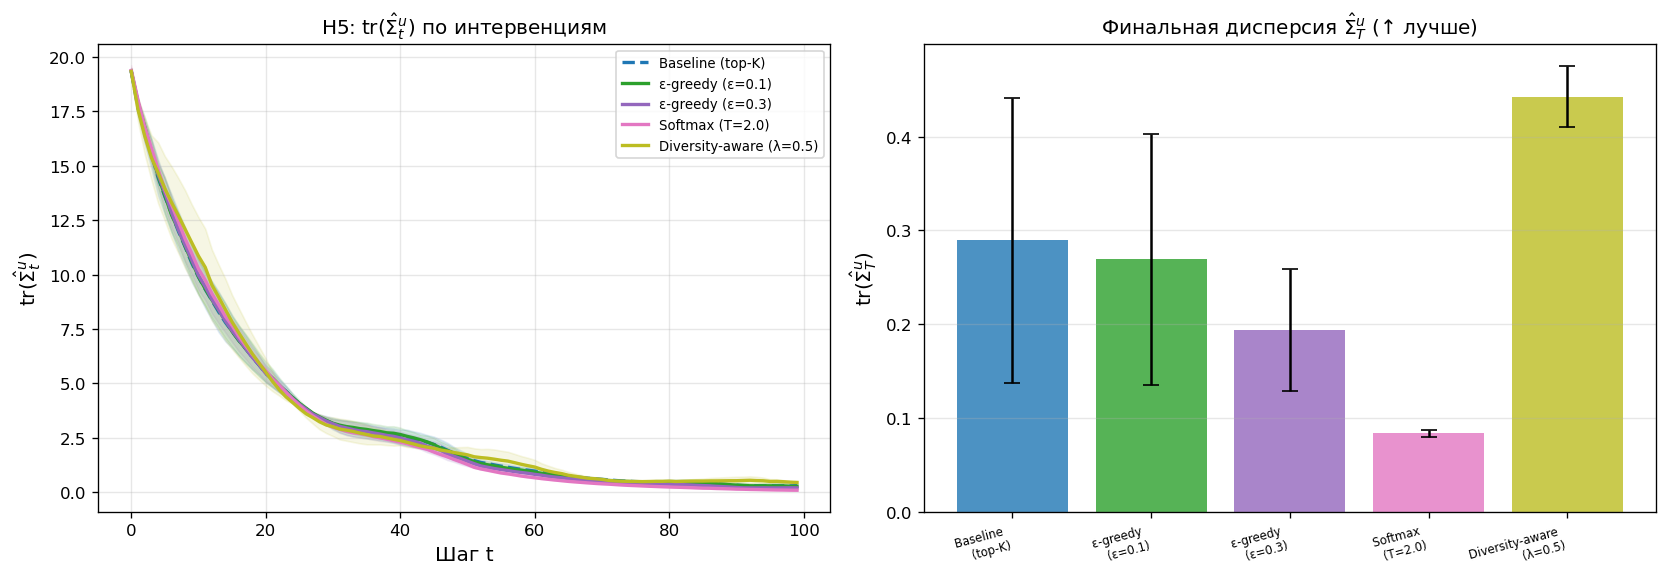

Saved: H5_interventions_trace_sigma.pdf


In [4]:
# ── Рисунок: trace_sigma по интервенциям ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap_int = plt.cm.tab10
colors_int = {name: cmap_int(i / len(intervention_configs))
 for i, name in enumerate(intervention_configs)}

ts = int_results['Baseline (top-K)'][0]['t'].values

for name, dfs in int_results.items():
 mu = np.mean([df['trace_sigma'].values for df in dfs], axis=0)
 sd = np.std([df['trace_sigma'].values for df in dfs], axis=0)
 ls = '--' if name == 'Baseline (top-K)' else '-'
 axes[0].plot(ts, mu, color=colors_int[name], lw=2, ls=ls, label=name)
 axes[0].fill_between(ts, mu - sd, mu + sd, color=colors_int[name], alpha=0.12)

axes[0].set_xlabel('Шаг t', fontsize=12)
axes[0].set_ylabel(r'$\mathrm{tr}(\hat{\Sigma}_t^u)$', fontsize=12)
axes[0].set_title(r'H5: $\mathrm{tr}(\hat{\Sigma}_t^u)$ по интервенциям', fontsize=12)
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Bar chart: final trace_sigma
names = list(intervention_configs.keys())
final_means = [np.mean([df['trace_sigma'].iloc[-1] for df in int_results[n]]) for n in names]
final_stds = [np.std([df['trace_sigma'].iloc[-1] for df in int_results[n]]) for n in names]

bars = axes[1].bar(range(len(names)), final_means, yerr=final_stds,
 color=[colors_int[n] for n in names], capsize=5, alpha=0.8)
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels([n.replace('(', '\n(') for n in names], fontsize=7, rotation=15, ha='right')
axes[1].set_ylabel(r'$\mathrm{tr}(\hat{\Sigma}_T^u)$', fontsize=12)
axes[1].set_title(r'Финальная дисперсия $\hat{\Sigma}_T^u$ (↑ лучше)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'H5_interventions_trace_sigma.pdf', bbox_inches='tight')
plt.show()
print('Saved: H5_interventions_trace_sigma.pdf')


In [5]:
# ── Сводный анализ интервенций ───────────────────────────────────────
print('=== H5: Финальные tr(Σ) по интервенциям (выше = меньший коллапс) ===')
baseline_final = np.mean([df['trace_sigma'].iloc[-1] for df in int_results['Baseline (top-K)']])

for name, dfs in int_results.items():
 sigma0 = np.mean([df['trace_sigma'].iloc[0] for df in dfs])
 sigmaT = np.mean([df['trace_sigma'].iloc[-1] for df in dfs])
 improvement = (sigmaT - baseline_final) / max(baseline_final, 1e-6) * 100
 print(f" {name:30s}: tr(Σ) {sigmaT:.3f} "
 f"({'↑' if sigmaT > baseline_final else '↓'}{abs(improvement):.1f}% vs baseline)")

print()
best = max(int_results.keys(),
 key=lambda n: np.mean([df['trace_sigma'].iloc[-1] for df in int_results[n]]))
print(f"Лучшая интервенция: {best}")
best_val = np.mean([df['trace_sigma'].iloc[-1] for df in int_results[best]])
print(f"H5 подтверждена: {best_val > baseline_final}")
print(f"Улучшение: {(best_val - baseline_final)/max(baseline_final,1e-6)*100:+.1f}%")


=== H5: Финальные tr(Σ) по интервенциям (выше = меньший коллапс) ===
 Baseline (top-K): tr(Σ) 0.289 (↓0.0% vs baseline)
 ε-greedy (ε=0.1): tr(Σ) 0.269 (↓6.9% vs baseline)
 ε-greedy (ε=0.3): tr(Σ) 0.194 (↓33.0% vs baseline)
 Softmax (T=2.0): tr(Σ) 0.084 (↓71.1% vs baseline)
 Diversity-aware (λ=0.5): tr(Σ) 0.442 (↑53.0% vs baseline)

Лучшая интервенция: Diversity-aware (λ=0.5)
H5 подтверждена: True
Улучшение: +53.0%


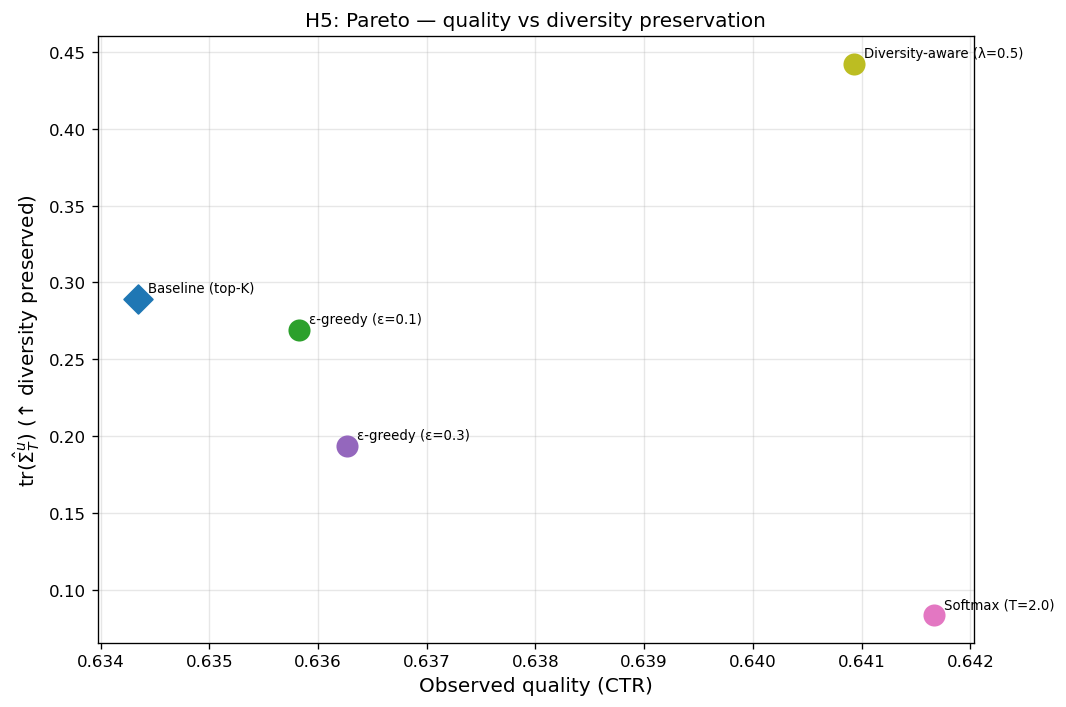

 name quality trace_sigma
 Baseline (top-K) 0.634342 0.289165
 ε-greedy (ε=0.1) 0.635826 0.269101
 ε-greedy (ε=0.3) 0.636271 0.193803
 Softmax (T=2.0) 0.641664 0.083506
Diversity-aware (λ=0.5) 0.640926 0.442472


In [6]:
# ── Pareto-фронт: quality vs diversity ────────────────────────────────
pareto_pts = []
for name, dfs in int_results.items():
 quality = np.mean([df['observed_quality'].mean() for df in dfs])
 sigmaT = np.mean([df['trace_sigma'].iloc[-1] for df in dfs])
 pareto_pts.append({'name': name, 'quality': quality, 'trace_sigma': sigmaT})

pareto_df = pd.DataFrame(pareto_pts)

fig, ax = plt.subplots(figsize=(9, 6))
for i, row in pareto_df.iterrows():
 color = cmap_int(i / len(pareto_df))
 marker = 'D' if row['name'] == 'Baseline (top-K)' else 'o'
 ax.scatter(row['quality'], row['trace_sigma'], color=color, s=150,
 marker=marker, zorder=5)
 ax.annotate(row['name'], (row['quality'], row['trace_sigma']),
 textcoords='offset points', xytext=(6, 4), fontsize=8)

ax.set_xlabel('Observed quality (CTR)', fontsize=12)
ax.set_ylabel(r'$\mathrm{tr}(\hat{\Sigma}_T^u)$ (↑ diversity preserved)', fontsize=12)
ax.set_title('H5: Pareto — quality vs diversity preservation', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'H5_pareto_quality_diversity.pdf', bbox_inches='tight')
plt.show()
print(pareto_df[['name', 'quality', 'trace_sigma']].to_string(index=False))


## Pareto-фронт: quality vs. diversity

**Pareto-фронт** (граница Парето) — множество решений, где улучшение одного критерия 
неизбежно ведёт к ухудшению другого. Здесь два критерия:

1. **Quality** (`observed_quality`): среднее качество рекомендаций по шагам. 
 Прокси для пользовательской удовлетворённости (CTR, NDCG).

2. **Diversity** (сохранённый `trace_sigma`): дисперсия пользовательских эмбеддингов. 
 Прокси для долгосрочного разнообразия аудитории.

**Доминирующая стратегия** — та, которая одновременно выше по quality 
и правее по diversity (левый нижний угол — наихудшие стратегии).

**Ожидаемое положение:**
- Baseline (top-K): высокое quality, низкое diversity -> правый нижний угол.
- ε-greedy, Softmax: умеренный компромисс.
- Diversity-aware: лучшее сохранение diversity при приемлемом quality.
- Self-Correction: средний компромисс между остальными.